<table align="left" width="100%"> <tr>
 <td style="background-color:#ffffff;"><a href=https://qworld.net/index.php/qworld/" target="_blank"><img src="../images/qworld.jpg" width="35%" align="left"></a></td>
 <td align="right" style="background-color:#ffffff;vertical-align:bottom;horizontal-align:right">
 prepared by Özlem Salehi (<a href="https://qworld.net/index.php/qturkey/" target="_blank">QTurkey</a>)
 </td>
</tr></table>

<table width="100%"><tr><td style="color:#555555;background-color:#f5f5f5;font-size:12px;font-style:italic;">This notebook is a **Qiskit port** of QWorld Silver's original notebook (Cirq), prepared by Ahmed Elghadban for QSaudi Arabia's QSilver39 course. Task 1 is on-paper math and is unchanged; Tasks 2-4 (the step-by-step order-finding circuit for x=7, N=15) are rewritten for Qiskit. Per the course's 4-day schedule, D06 is not part of live teaching - it's included here as trainee-guide self-study material, going deeper into the intuition behind D05's phase-estimation and order-finding steps. Original content © QWorld, CC BY 4.0.</td></tr></table>

<table width="100%"><tr><td style="color:#bbbbbb;background-color:#ffffff;font-size:11px;font-style:italic;text-align:right;">This cell contains some macros. If there is a problem with displaying mathematical formulas, please run this cell to load these macros. </td></tr></table>
$\newcommand{\Mod}[1]{\ (\mathrm{mod}\ #1)}$
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\ \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0} } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1} } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $

<h1> <font color="blue"> Solutions for </font> Shor's Algorithm In More Detail</h1>

<a id="task1"></a>
<h3>Task 1 (on paper)</h3>

Show that after applying the controlled $U^{2^j}$ gates for $j=0,\dots,t-1$, the state obtained can be expressed as $\displaystyle \frac{1}{2^{t/2}} \sum_{k=0}^{2^t-1} \ket{k}U^k\ket{\psi}$. 

<h3>Solution</h3>

We have already seen the effect of the first gate corresponding to case $j=0$. Let's continue with the remaining gates.

- $ j=0 $, qubit $ t$ is the control.

If $ k_t=0 $, new state is $\ket{k} \ket{\psi} $. If $ k_t=1 $, new state is $ e^{2\pi i \phi 2^0} \ket{k} \ket{\psi} $.

Hence, we can write it as, $\ket{k} U^{k_t 2 ^0} \ket{\psi}.$

- $ j=1 $, qubit $ t-1 $ is the control.

If $ k_{t-1}=0 $, new state is $ \ket{k} U^{k_t 2 ^0} \ket{\psi} $. If $ k_{t-1}=1 $, new state is $ \ket{k} e^{2\pi i \phi 2^1} U^{k_t 2 ^0} \ket{\psi} $.

Hence, we can write it as, $\ket{k} U^{k_{t-1} 2 ^1} U^{k_t 2 ^0} \ket{\psi}$

Applying the $ CU^{2^j} $ gates for each qubit, we obtain the following state at the end.

$
\ket{k} U^{k_1 (2^t-1)} \cdots U^{k_{t-1} 2^1} U^{k_t 2^0} \ket{\psi} = \ket{k} U^{k_1 (2^t-1)+\cdots +k_{t-1} 2^1+ k_t 2^0} \ket{\psi} 
 $

Now noting that $ k_1 (2^t-1)+\cdots +k_{t-1} 2^1+k_t 2^0=k $, we can express the state obtained as $\displaystyle \frac{1}{2^{t/2}} \sum_{k=0}^{2^t-1} \ket{k}U^k\ket{\psi}$.	

<a id="task2"></a>
<h3>Task 2</h3>

Implement the order finding procedure until the Inverse Quantum Fourier Transform and check whether you obtain the above state. Simulate the circuit without measuring it. Use the function <i>dirac_notation()</i> to print the state representation after getting the results. Check the first 5 states, convert to integer representation and compare with the above expression.

Recall that to implement $CU$ operator you should pass $x$ and $N$ as parameter to the function <i>Ux</i>. Run the following cell to load the function.

<pre>CU=Ux(x,N)</pre>

In [1]:
#Load the function Ux
from operator_cu import Ux

<h3>Solution</h3>

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from dirac_notation import dirac_notation

#Set t and n, sizes of the registers
t = 12
n = 4

#Create control and target qubits and the circuit
circuit = QuantumCircuit(t + n)
control = list(range(t))
target = list(range(t, t + n))
circuit.x(target[-1])

#Create the operator CU
x = 7
N = 15
CU = Ux(x, N)

#Apply Hadamard to control qubits
for q in control:
    circuit.h(q)

#Apply CU gates
for i in range(t):
    #Obtain the power of CU gate
    CUi = CU.power(2**i)
    #Apply CUi gate where t-i-1 is the control (target qubits reversed -
    #see qpe.py's docstring for why: Qiskit's first-qubit-passed-is-LSB
    #convention vs. this port's Cirq-style target[0]-is-MSB convention)
    circuit.append(CUi, [control[t - i - 1]] + list(reversed(target)))

#Get the statevector and print it using Dirac notation
state = Statevector.from_instruction(circuit)
print(dirac_notation(state))

0.01562|0000000000000001⟩ + 0.01562|0000000000010111⟩ + 0.01562|0000000000100100⟩ + 0.01562|0000000000111101⟩ + 0.01562|0000000001000001⟩ + 0.01562|0000000001010111⟩ + 0.01562|0000000001100100⟩ + 0.01562|0000000001111101⟩ + 0.01562|0000000010000001⟩ + 0.01562|0000000010010111⟩ + 0.01562|0000000010100100⟩ + 0.01562|0000000010111101⟩ + 0.01562|0000000011000001⟩ + 0.01562|0000000011010111⟩ + 0.01562|0000000011100100⟩ + 0.01562|0000000011111101⟩ + 0.01562|0000000100000001⟩ + 0.01562|0000000100010111⟩ + 0.01562|0000000100100100⟩ + 0.01562|0000000100111101⟩ + 0.01562|0000000101000001⟩ + 0.01562|0000000101010111⟩ + 0.01562|0000000101100100⟩ + 0.01562|0000000101111101⟩ + 0.01562|0000000110000001⟩ + 0.01562|0000000110010111⟩ + 0.01562|0000000110100100⟩ + 0.01562|0000000110111101⟩ + 0.01562|0000000111000001⟩ + 0.01562|0000000111010111⟩ + 0.01562|0000000111100100⟩ + 0.01562|0000000111111101⟩ + 0.01562|0000001000000001⟩ + 0.01562|0000001000010111⟩ + 0.01562|0000001000100100⟩ + 0.01562|000000100011

Let's check the first 5 states. The first 12 bits represent the first register and the last 4 bits represent the second register.

$\ket{000000000000}\ket{0001} = \ket{0}\ket{1}$

$\ket{000000000001}\ket{0111} = \ket{1}\ket{7}$

$\ket{000000000010}\ket{0100} = \ket{2}\ket{4}$

$\ket{000000000011}\ket{1101} = \ket{3}\ket{13}$

$\ket{000000000100}\ket{0001} = \ket{4}\ket{1}$

<a id="task3"></a>
<h3>Task 3</h3>

Measure the second register and sample the circuit. Next, simulate the circuit and print the obtained state using <i>dirac_notation()</i>. Check the first five states and convert to integer representation.

<h3>Solution</h3>

In [3]:
from qiskit_aer import AerSimulator
from qiskit import transpile

#Build a copy of the circuit with the target register measured into its
#own classical register, for a 1000-shot histogram of the second register
sample_circuit = QuantumCircuit(t + n, n)
sample_circuit.compose(circuit, inplace=True)
sample_circuit.measure(target, range(n))

#Sample the circuit
print('Sample the circuit:')
sim = AerSimulator()
result = sim.run(transpile(sample_circuit, sim), shots=1000).result()
counts = result.get_counts()

#Decode the target register's classical bits into an integer (reverse -
#same convention used throughout this port, see qpe.py)
from collections import Counter
target_hist = Counter()
for bits, cnt in counts.items():
    target_hist[int(bits[::-1], 2)] += cnt
print(dict(sorted(target_hist.items())))

#Simulate a single run: measuring only the target register collapses it
#to one outcome, leaving the control register in the corresponding
#superposition - Statevector.measure() does exactly this
outcome, collapsed = state.measure(target)
print("Second register measured as:", outcome[::-1], "=", int(outcome[::-1], 2))
print(dirac_notation(collapsed))

Sample the circuit:
{1: 248, 4: 224, 7: 272, 13: 256}
Second register measured as: 0100 = 4
0.03125|0000000000100100⟩ + 0.03125|0000000001100100⟩ + 0.03125|0000000010100100⟩ + 0.03125|0000000011100100⟩ + 0.03125|0000000100100100⟩ + 0.03125|0000000101100100⟩ + 0.03125|0000000110100100⟩ + 0.03125|0000000111100100⟩ + 0.03125|0000001000100100⟩ + 0.03125|0000001001100100⟩ + 0.03125|0000001010100100⟩ + 0.03125|0000001011100100⟩ + 0.03125|0000001100100100⟩ + 0.03125|0000001101100100⟩ + 0.03125|0000001110100100⟩ + 0.03125|0000001111100100⟩ + 0.03125|0000010000100100⟩ + 0.03125|0000010001100100⟩ + 0.03125|0000010010100100⟩ + 0.03125|0000010011100100⟩ + 0.03125|0000010100100100⟩ + 0.03125|0000010101100100⟩ + 0.03125|0000010110100100⟩ + 0.03125|0000010111100100⟩ + 0.03125|0000011000100100⟩ + 0.03125|0000011001100100⟩ + 0.03125|0000011010100100⟩ + 0.03125|0000011011100100⟩ + 0.03125|0000011100100100⟩ + 0.03125|0000011101100100⟩ + 0.03125|0000011110100100⟩ + 0.03125|0000011111100100⟩ + 0.03125|0000

In our case, the second register is measured as $\ket{1101}$ which is $\ket{13}$. Note that you might get a different measurement result. Let's check the first 5 states.

$\ket{000000000011}=\ket{3}$ 

$\ket{000000000111} = \ket{7}$

$\ket{000000001011} = \ket{11}$

$\ket{000000001111} = \ket{15}$ 

$\ket{000000010011} = \ket{19}$

<a id="task4"></a>
<h3>Task 4</h3>

Apply $QFT^{\dagger}$ to the first register and measure (Don't forget to provide a different key for measurement). Sample the circuit and check whether you get the outcomes 0, 1024, 2048 and 3072.

In [4]:
#Load the inverse QFT function (qpe.py already uses it internally,
#we just need it standalone here to apply it to only the control register)
from iqft import iqft

<h3>Solution</h3>

In [5]:
#Build a fresh copy of the circuit that also measures the target
#register (same measurement as Task 3, just resampled), then applies
#inverse QFT to the control register before measuring that too
full_circuit = QuantumCircuit(t + n, t + n)
full_circuit.compose(circuit, inplace=True)

#Measure the target register (same measurement as Task 3)
full_circuit.measure(target, range(t, t + n))

#Call inverse qft method on the control register
iqft(t, control, full_circuit)

#Measure the control register into a different set of classical bits
full_circuit.measure(control, range(t))

#Sample the circuit
print('Sample the circuit:')
result = sim.run(transpile(full_circuit, sim), shots=1000).result()
counts = result.get_counts()

#Decode the control register's classical bits into an integer (reverse -
#control[0] is the most-significant bit, same convention as qpe.py)
control_hist = Counter()
for bits, cnt in counts.items():
    control_hist[int(bits[-t:][::-1], 2)] += cnt

results = dict(sorted(control_hist.items()))
print(results)

Sample the circuit:
{0: 236, 1024: 256, 2048: 261, 3072: 247}


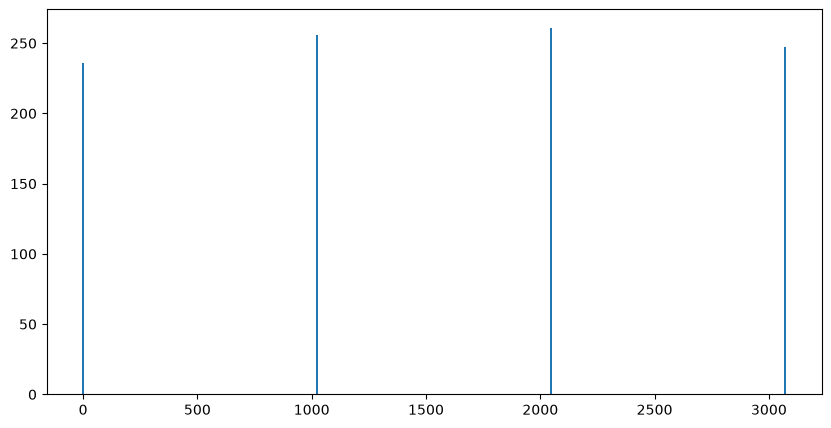

In [6]:
import matplotlib.pyplot as plt
freqs = list(results.values())
states = list(results.keys())
fig = plt.figure(figsize = (10, 5))
plt.bar(states, freqs, width = 10)
plt.show()